In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#importing ml models to use
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier

# import ML tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.pipeline import Pipeline
import pickle

import warnings
warnings.filterwarnings("ignore")

#1.Data load and Assessing

In [ ]:
# to see all the columns
pd.set_option('display.max_columns', None)
# upload and overview of dataset
df = pd.read_csv('/content/cancer patient data sets.csv')
df

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,7,7,7,7,7,8,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,7,7,7,8,7,7,5,3,2,7,8,2,4,5,3,High
996,996,P996,37,2,6,8,7,7,7,6,7,7,7,8,7,7,9,6,5,7,2,4,3,1,4,High
997,997,P997,25,2,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High
998,998,P998,18,2,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2,4,2,3,High


In [ ]:
df.shape

(1000, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()/df.shape[0]*100

,0
index,0.0
Patient Id,0.0
Age,0.0
Gender,0.0
Air Pollution,0.0
Alcohol use,0.0
Dust Allergy,0.0
OccuPational Hazards,0.0
Genetic Risk,0.0
chronic Lung Disease,0.0


#2.Data Cleaning and Preprocessing

**Framing of ML problem?**

- It is a **Multiclass supervised classification problem**

##2.1.Drop unnecessary features

In [ ]:
# drop Patient Id' and index
df.drop(['Patient Id','index'],axis=1,inplace=True)
df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,7,7,7,8,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2,4,2,3,High


##2.2.Prepare Features and Target

In [ ]:
X = df.drop(columns=['Level'])
y = df['Level']

# Encode target labels (Low, Medium, High to 0,1,2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
models = {
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),

    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Bagging": BaggingClassifier(random_state=42),

    "SGD Classifier": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(max_iter=1000, random_state=42))
    ]),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
}

In [ ]:
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy'
    )
    cv_scores[name] = scores.mean()

In [ ]:
cv_results_df = pd.DataFrame({
    'Model': cv_scores.keys(),
    'CV Accuracy': cv_scores.values()
}).sort_values(by='CV Accuracy', ascending=False)

cv_results_df

,Model,CV Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
9,XGBoost,1.000000
3,Logistic Regression,1.000000
4,SVM,1.000000
6,Gradient Boosting,1.000000
7,Bagging,1.000000
8,SGD Classifier,0.997143
0,KNN,0.994286
5,AdaBoost,0.948571


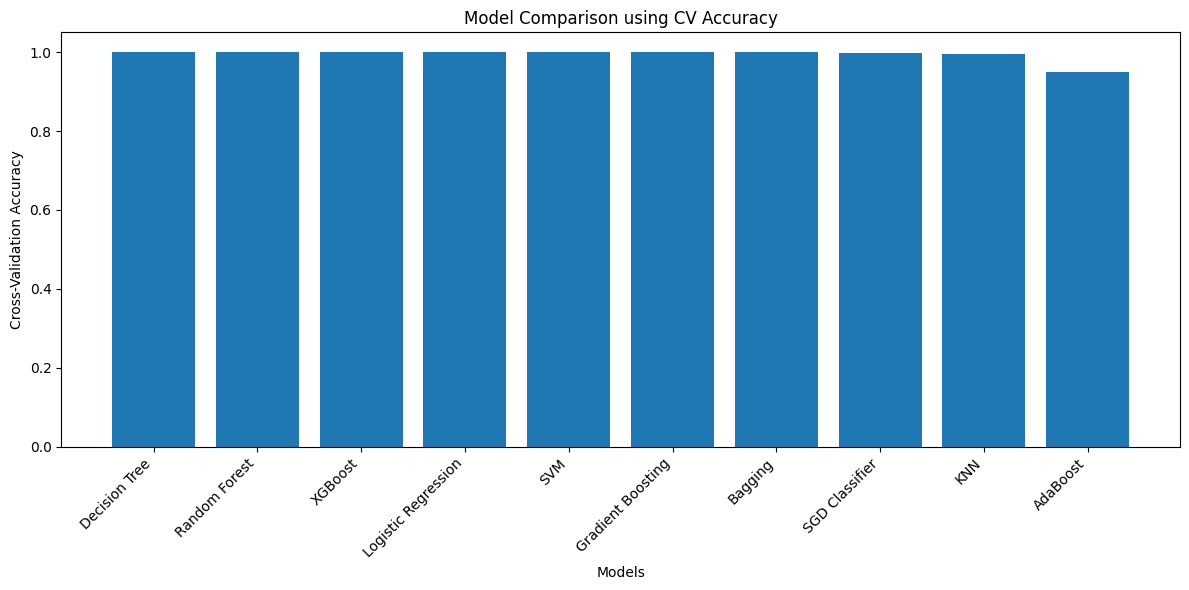

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(cv_results_df['Model'], cv_results_df['CV Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Models")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Model Comparison using CV Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       109
         Low       1.00      1.00      1.00        91
      Medium       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



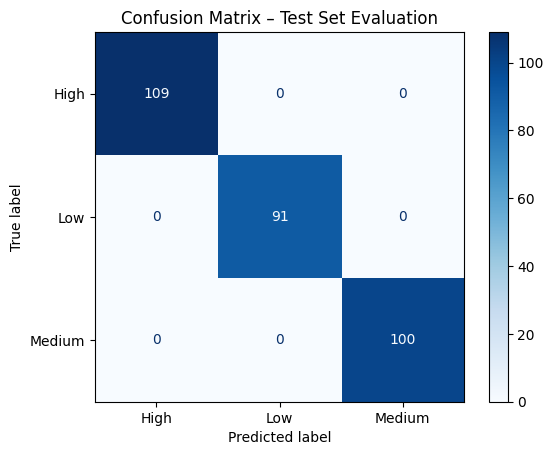

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Test Set Evaluation")
plt.show()

In [ ]:
with open("lung_cancer_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)